# PERTEMUAN 9 — ALGORITMA KLASIFIKASI (BAGIAN 1)

**Nama:** Suryani Tangdiaga  
**NIM:** 250401020097  
**Kelas:** IF405
 

## Materi
- Logistic Regression
- Decision Tree
- Evaluasi Model Klasifikasi
- Confusion Matrix
- Accuracy, Precision, Recall, dan F1-Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Library berhasil dimuat.")

Library berhasil dimuat.


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Shape data:", X.shape)
print("Jumlah fitur:", X.shape[1])
print("Jumlah kelas:", len(np.unique(y)))

print("\nDistribusi target:")
print(pd.Series(y).value_counts())

Shape data: (569, 30)
Jumlah fitur: 30
Jumlah kelas: 2

Distribusi target:
1    357
0    212
Name: count, dtype: int64


In [3]:
print("Distribusi target:")
print(pd.Series(y).value_counts(normalize=True).round(3))

Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)
print("Preprocessing selesai.")

Data training : (455, 30)
Data testing  : (114, 30)
Preprocessing selesai.


In [5]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

print("Logistic Regression selesai dilatih.")

Logistic Regression selesai dilatih.


In [6]:
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    'Koefisien',
    key=abs,
    ascending=False
)

print(coef_df.head(10))

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616
28        worst symmetry  -0.939181
13            area error  -0.929104
26       worst concavity  -0.823151
22       worst perimeter  -0.763220
24      worst smoothness  -0.746625


In [7]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree selesai dilatih.")

Decision Tree selesai dilatih.


In [8]:
print("=== Evaluasi Logistic Regression ===")

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1-Score :", f1_score(y_test, y_pred_log))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=data.target_names
    )
)

=== Evaluasi Logistic Regression ===
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1-Score : 0.9861111111111112

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [9]:
print("=== Evaluasi Decision Tree ===")

print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1-Score :", f1_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=data.target_names
    )
)

=== Evaluasi Decision Tree ===
Accuracy : 0.9385964912280702
Precision: 0.9577464788732394
Recall   : 0.9444444444444444
F1-Score : 0.951048951048951

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



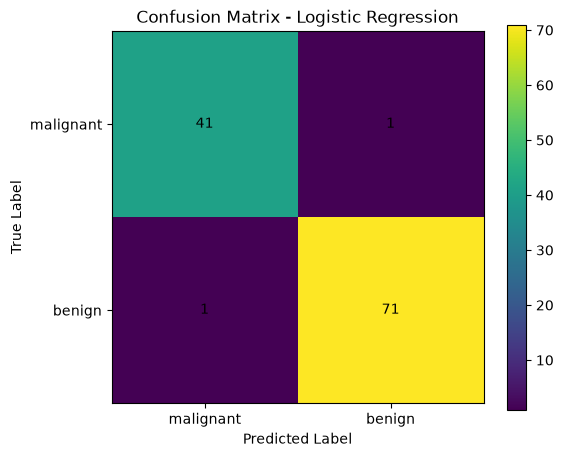

In [10]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))

plt.imshow(cm_log, interpolation='nearest')
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

plt.xticks([0, 1], data.target_names)
plt.yticks([0, 1], data.target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_log.shape[0]):
    for j in range(cm_log.shape[1]):
        plt.text(j, i, cm_log[i, j],
                 ha="center",
                 va="center")

plt.show()

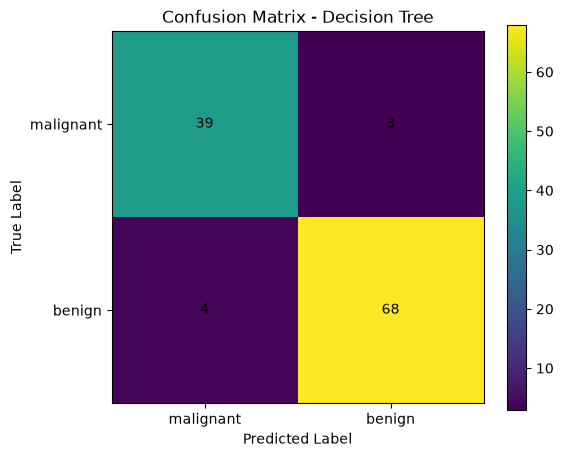

In [11]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))

plt.imshow(cm_tree, interpolation='nearest')
plt.title("Confusion Matrix - Decision Tree")
plt.colorbar()

plt.xticks([0, 1], data.target_names)
plt.yticks([0, 1], data.target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_tree.shape[0]):
    for j in range(cm_tree.shape[1]):
        plt.text(j, i, cm_tree[i, j],
                 ha="center",
                 va="center")

plt.show()

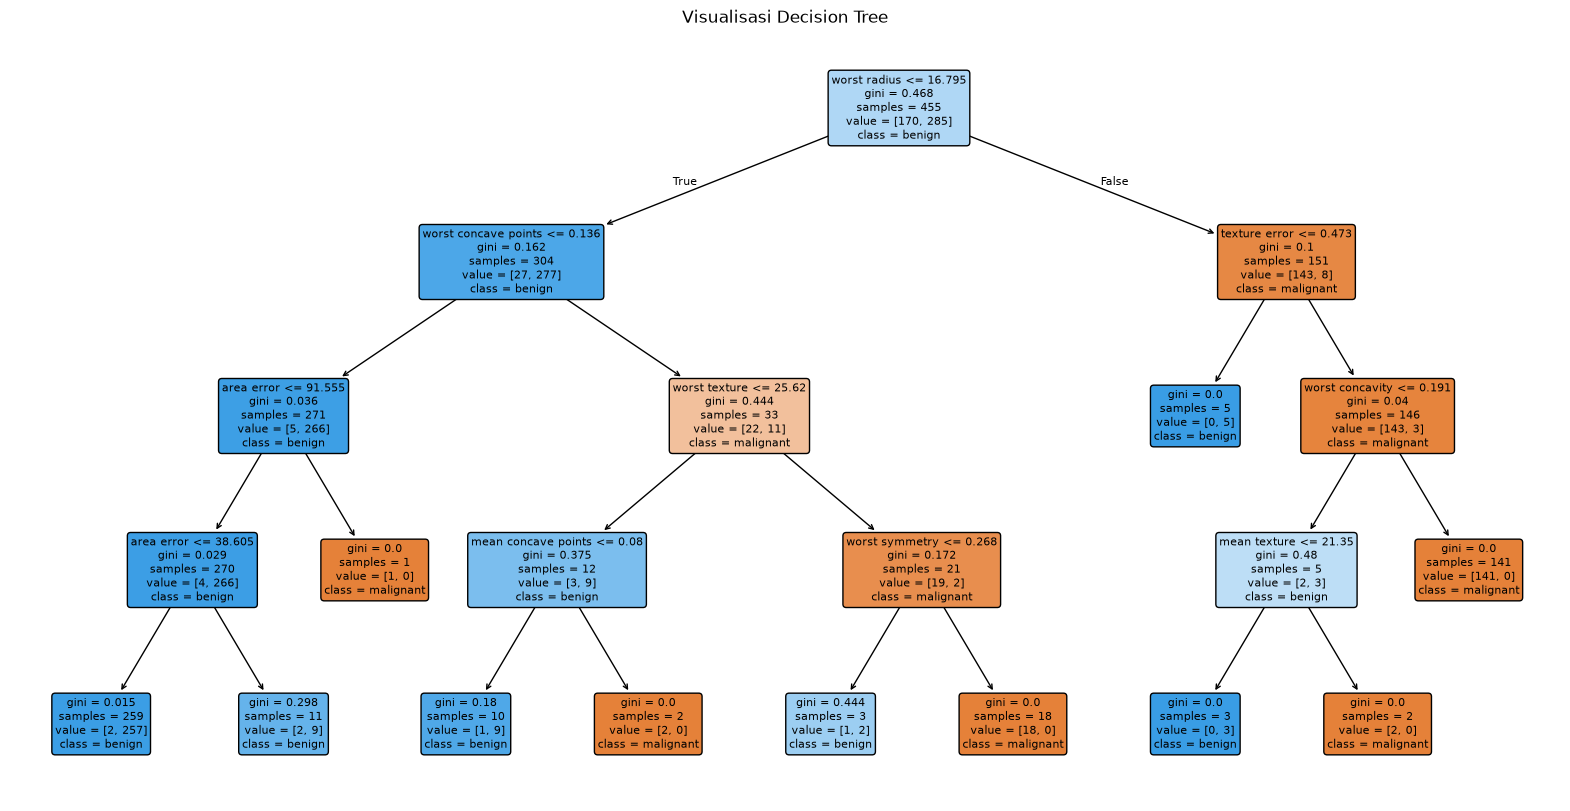

In [12]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Visualisasi Decision Tree")
plt.show()

In [13]:
hasil_model = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ]
})

hasil_model

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.938596,0.957746,0.944444,0.951049


# Kesimpulan

Pada Pertemuan 9 telah dipelajari algoritma klasifikasi menggunakan dataset Breast Cancer dari Scikit-Learn. Dua algoritma yang digunakan adalah Logistic Regression dan Decision Tree.

Tahapan yang dilakukan meliputi persiapan dataset, pembagian data menjadi data training dan testing, preprocessing menggunakan StandardScaler untuk Logistic Regression, pelatihan model, prediksi, serta evaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.

Logistic Regression digunakan sebagai model klasifikasi berbasis hubungan linear antar fitur, sedangkan Decision Tree menggunakan struktur pohon keputusan untuk menentukan kelas berdasarkan kondisi pada fitur. Hasil evaluasi menunjukkan bahwa kedua model mampu melakukan klasifikasi pada dataset dengan performa yang baik, meskipun terdapat perbedaan pada masing-masing metrik evaluasi.

Visualisasi Decision Tree juga membantu memahami bagaimana model mengambil keputusan berdasarkan fitur-fitur yang tersedia.

### Temuan Utama

- Dataset Breast Cancer memiliki dua kelas target dan 30 fitur.
- Logistic Regression dapat digunakan untuk klasifikasi setelah data numerik dilakukan scaling.
- Decision Tree dapat digunakan tanpa StandardScaler karena model berbasis aturan pemisahan data.
- Confusion Matrix membantu melihat jumlah prediksi benar dan salah pada setiap kelas.
- Accuracy, Precision, Recall, dan F1-Score digunakan untuk mengukur performa model dari beberapa sudut pandang.

### Keterbatasan

Dataset yang digunakan merupakan dataset yang sudah tersedia dari Scikit-Learn sehingga belum menggambarkan seluruh permasalahan pada dataset dunia nyata. Selain itu, model yang digunakan masih menggunakan konfigurasi dasar dan belum dilakukan optimasi hyperparameter secara mendalam.

Pada penelitian atau pembelajaran selanjutnya, model dapat dikembangkan dengan menggunakan metode seperti Grid Search, Cross Validation, Random Forest, Support Vector Machine, atau algoritma klasifikasi lainnya.